#Note
1. please use comments in code. We are all adults working on the project, and we can't read each other's minds.
2. Colab has some... issues... with multiple people accessing the document at once. Best practice is to save often, and do NOT overwrite someone elses work when automatic failing goes down. Simply copy&paste changes you made into a seperate location, refresh the page, then paste&save the changes.

In [ ]:
#please import all libraries here, at the head of the program
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl # is this a good idea?
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split



campaign = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')
campaign.tail() #tail instead of head, just to get a total count of rows

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
37064,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
37065,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
37066,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
37067,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
37068,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [ ]:
bins = [1, 2,3,4,5]
labels = ["1-2%", "2-3%","3-4%","4-5%"]

campaign["euribor_bin"] = pd.cut(
    campaign["euribor3m"],
    bins=bins,
    labels=labels,
    right=False
)

In [ ]:
bins = [18, 25, 35, 45, 55, 65, float("inf")]
labels = ["18–24", "25–34", "35–44", "45–54", "55–64", "65+"]
campaign["age_bin"] = pd.cut(
    campaign["age"],
    bins=bins,
    labels=labels,
    right=False  # left-inclusive: 18–24 means [18, 25)
)

campaign["age_bin"].value_counts()

X = pd.get_dummies(campaign.drop(columns=["age"]), drop_first=True)
y = campaign["y"]

Binning Categoriocal jobs

In [ ]:
job_map = {
    "admin.": "white_collar",
    "management": "white_collar",
    "technician": "white_collar",

    "services": "service",
    "housemaid": "service",

    "blue-collar": "manual",

    "entrepreneur": "self_employed",
    "self-employed": "self_employed",

    "student": "limited_income",
    "retired": "limited_income",

    "unemployed": "limited_income",

    "unknown": "unknown"
}

campaign["job_group"] = campaign["job"].map(job_map)


seasons

In [ ]:
season_map = {
    "jan": "winter",
    "feb": "winter",
    "mar": "spring",
    "apr": "spring",
    "may": "spring",
    "jun": "summer",
    "jul": "summer",
    "aug": "summer",
    "sep": "fall",
    "oct": "fall",
    "nov": "fall",
    "dec": "winter"
}

campaign["season"] = campaign["month"].map(season_map)


educaion


In [ ]:
education_map = {
    "primary": "low",
    "secondary": "medium",
    "tertiary": "high",
    "unknown": "unknown"
}

campaign["education_group"] = campaign["education"].map(education_map)


weekends


In [ ]:
weekday_map = {
    "mon": "weekday",
    "tue": "weekday",
    "wed": "weekday",
    "thu": "weekday",
    "fri": "weekday",
    "sat": "weekend",
    "sun": "weekend"
}

campaign["day_group"] = campaign["day_of_week"].map(weekday_map)


In [ ]:
# lazy proscessing, feel free to modify/improve
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.utils.class_weight import compute_class_weight
#removing blank values (needs improvement)


#one-hot encode has been done on on job, marital, education
#label encode has been done on all yes/no columns, as well as day.


# campaign_ml = pd.get_dummies(campaign_ml, columns=["job"])
# campaign_ml = pd.get_dummies(campaign_ml, columns=["marital"])
# campaign_ml = pd.get_dummies(campaign_ml, columns=["education"])
 # Source - https://stackoverflow.com/q
# Posted by Night Walker, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-28, License - CC BY-SA 4.0




features = ['job_group', 'marital', 'education_group', 'age_bin','housing','loan', 'season', 'day_group','previous','contact']
# features_2 = ['default', 'housing', 'loan', 'day_of_week']

X = pd.get_dummies(campaign[features], drop_first=True)

y = campaign['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=46)

# Build the decision tree
# we want to find someone who says yes,

# anything to make sure accouting for the fact that yeses are more valuable?

# bin
# feature

# f1_score

# we are tyring to find, of the ones that are yes, is improving the recall score. how of the ones that are yes, how many were predicted rightly
#

# max_depth  = 4
# class weight = balcc


clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,              # 👈 not too deep
    min_samples_leaf=20,      # 👈 forces minority coverage
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
# you can see how much better it makes it, 10 splits is not any better than 4

# Train it
clf.fit(X_train, y_train)

# Test it
clf.score(X_test, y_test)


recall = recall_score(y_test, clf.predict(X_test), pos_label='yes')
y_pred = clf.predict(X_test)
print(recall)
# print(y_pred)



# campaign_ml["default_encoded"] = pd.factorize(campaign_ml["default"])[0]
# campaign_ml["housing_encoded"] = pd.factorize(campaign_ml["housing"])[0]
# campaign_ml["loan_encoded"] = pd.factorize(campaign_ml["loan"])[0]
# campaign_ml["day_of_week_encoded"] = pd.factorize(campaign_ml["day_of_week"])[0]
# campaign_ml["y_encoded"] = pd.factorize(campaign_ml["y"])[0]




0.6282973621103117


Prediction probs

In [ ]:
# 1️⃣ Get predicted probabilities
y_pred_prob = clf.predict_proba(X_test)[:,1]  # probability of positive class ("yes")

# 2️⃣ Apply custom threshold
threshold = 0.3  # lower than default 0.5 to increase recall
y_pred = (y_pred_prob >= threshold).astype(int)


In [ ]:
importances = pd.Series(
    clf.feature_importances_,
    index=X.columns)


ValueError: Length of values (18) does not match length of index (22)

In [ ]:
threshold = 0.004
important_features = importances[importances > threshold].index

X_reduced = X[important_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.3, random_state=42
)


clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,              # 👈 not too deep
    min_samples_leaf=20,      # 👈 forces minority coverage
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)
clf.score(X_test, y_test)
recall = recall_score(y_test, clf.predict(X_test), pos_label='yes')
y_pred = clf.predict(X_test)
print(recall)


0.6398467432950191


Try to reduce unnecessary features

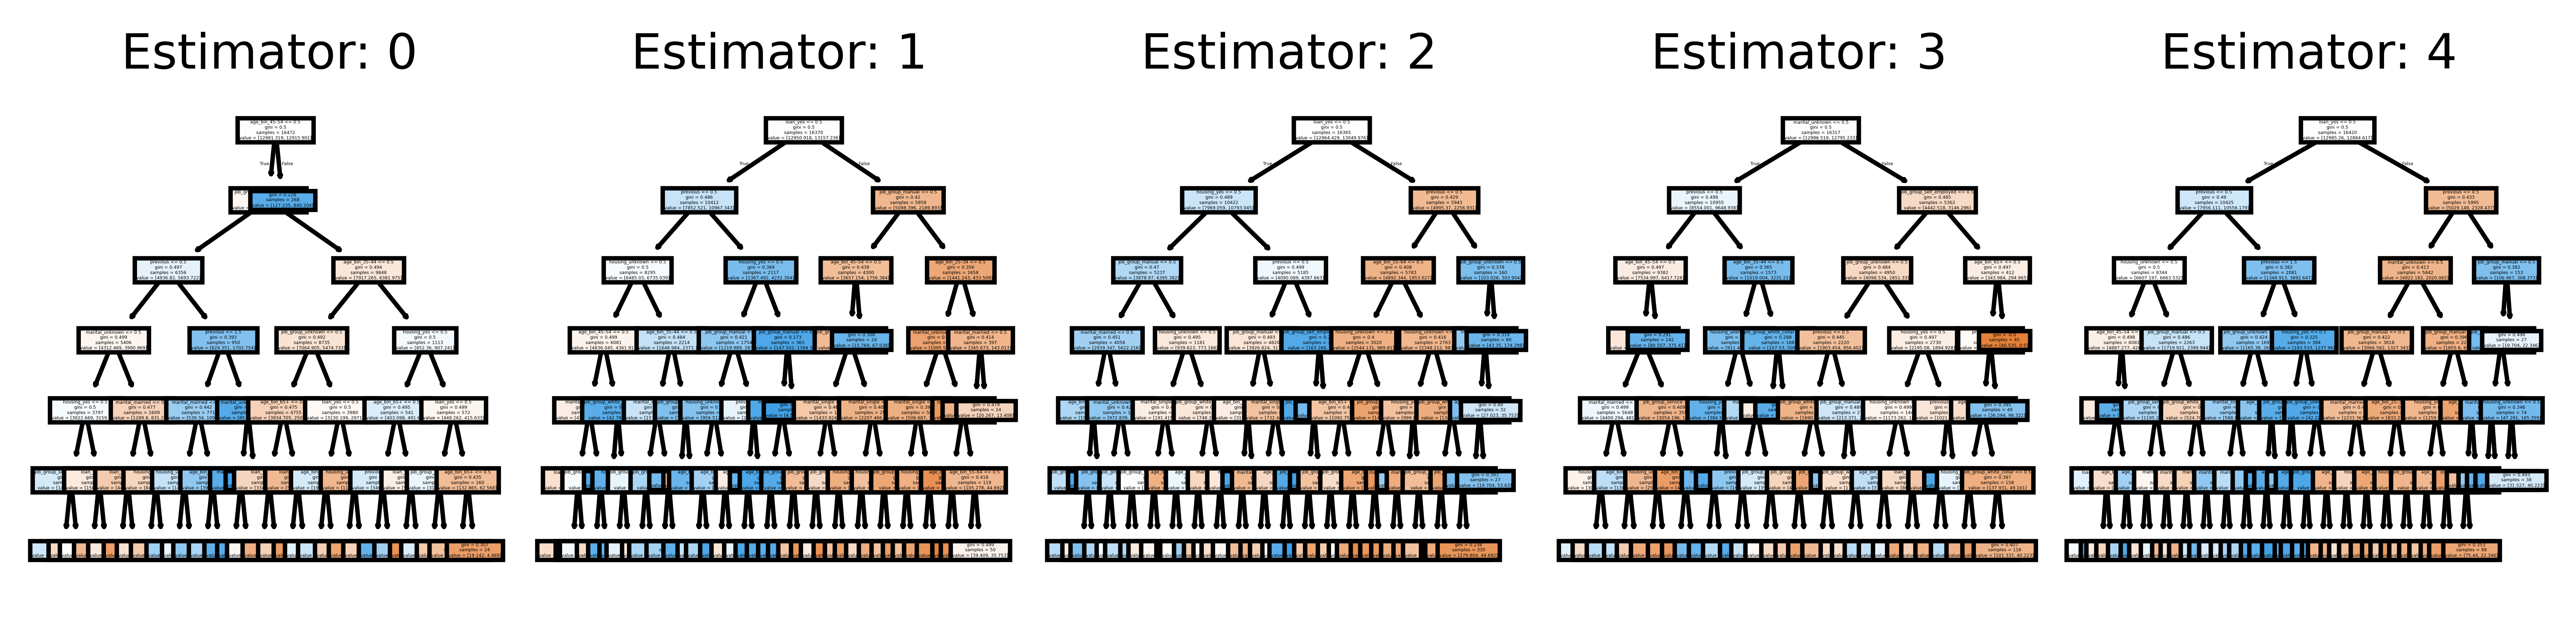

In [ ]:
fn=X.columns
# cn=y.target_names
fig, axes = plt.subplots(nrows = 1,ncols = 5,figsize = (10,2), dpi=900)
for index in range(0, 5):
    tree.plot_tree(clf.estimators_[index],
                   feature_names = fn,
                   filled = True,
                   ax = axes[index]);

    axes[index].set_title('Estimator: ' + str(index), fontsize = 11)
fig.savefig('rf_5trees.png')


#Holdout Code

In [ ]:
test = pd.read_csv("https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test_mini.csv")

features=
test_X = pd.get_dummies(test[features], drop_first=True)

test_X.tail()


SyntaxError: invalid syntax (ipython-input-3644906558.py, line 3)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

# -------------------------------
# Load test data
# -------------------------------
test = pd.read_csv(
    "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test_mini.csv"
)

# -------------------------------
# EURIBOR bin
# -------------------------------
bin_euribor = [1, 2, 3, 4, 5]
euribor_labels = ["1-2%", "2-3%", "3-4%", "4-5%"]

test["euribor_bin"] = pd.cut(
    test["euribor3m"],
    bins=bin_euribor,
    labels=euribor_labels,
    right=False
)

# -------------------------------
# Age bin
# -------------------------------
age_bins = [18, 25, 35, 45, 55, 65, float("inf")]
age_labels = ["18–24", "25–34", "35–44", "45–54", "55–64", "65+"]

test["age_bin"] = pd.cut(
    test["age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# -------------------------------
# Job grouping
# -------------------------------
job_map = {
    "admin.": "white_collar",
    "management": "white_collar",
    "technician": "white_collar",
    "services": "service",
    "housemaid": "service",
    "blue-collar": "manual",
    "entrepreneur": "self_employed",
    "self-employed": "self_employed",
    "student": "limited_income",
    "retired": "limited_income",
    "unemployed": "limited_income",
    "unknown": "unknown"
}

test["job_group"] = test["job"].map(job_map)

# -------------------------------
# Season bin
# -------------------------------
season_map = {
    "jan": "winter", "feb": "winter",
    "mar": "spring", "apr": "spring", "may": "spring",
    "jun": "summer", "jul": "summer", "aug": "summer",
    "sep": "fall", "oct": "fall", "nov": "fall",
    "dec": "winter"
}

test["season"] = test["month"].map(season_map)

# -------------------------------
# Education bin
# -------------------------------
education_map = {
    "primary": "low",
    "secondary": "medium",
    "tertiary": "high",
    "unknown": "unknown"
}

test["education_group"] = test["education"].map(education_map)

# -------------------------------
# Day grouping
# -------------------------------
weekday_map = {
    "mon": "weekday", "tue": "weekday", "wed": "weekday",
    "thu": "weekday", "fri": "weekday",
    "sat": "weekend", "sun": "weekend"
}

test["day_group"] = test["day_of_week"].map(weekday_map)

# -------------------------------
# Feature selection
# -------------------------------
features = [
    "job_group", "marital", "education_group", "age_bin",
    "housing", "loan", "season", "day_group",
    "previous", "contact"
]

# -------------------------------
# One-hot encode test set
# -------------------------------
X_test = pd.get_dummies(test[features], drop_first=True)

# 🔑 CRITICAL STEP: align columns with training set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# -------------------------------
# Train model (already trained in your notebook, shown here for completeness)
# -------------------------------
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

# -------------------------------
# Predict
# -------------------------------
predictions = clf.predict(X_test)

# -------------------------------
# Save predictions
# -------------------------------
my_predictions = pd.DataFrame(predictions, columns=["y"])
my_predictions.to_csv("team4-module2-predictions.csv", index=False)
